# L3b Advanced: Recombination and Computational Cost

A binomial price model has two related representations. The **full path tree** keeps every up/down history separate. The **recombined lattice** merges histories that reach the same state. This notebook makes that distinction concrete and answers two questions:

> Why do asymmetric moves with $d\neq 1/u$ still recombine, and what assumptions make recombination fail?

Both questions come down to the same observation about multiplication, which we develop below.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> - **Replacement versus recombination:** Explain why the up and down moves remain available at every step, and distinguish that sampling statement from the merging of different move orders at the same price node.
> - **Recombination:** Show that paths with the same number of up moves reach the same terminal price whenever the move factors are constant, even without any reciprocal restriction between them.
> - **Computational cost and its limit:** Compare the exponential number of path histories with the quadratic number of lattice nodes, and determine when time-dependent move factors prevent two path orders from merging.

Let's get started!
___

## Setup, Data, and Prerequisites

We load DataFrames and Plots from the course environment.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activates the course project and loads the [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), and [Statistics](https://docs.julialang.org/en/v1/stdlib/Statistics/) packages. There are no local source files beyond `Include.jl` itself.

Next, we set the default plot styling:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

___

## 1. Replacement describes the available moves

At every step, the model again offers the set $\{u,d\}$. In sampling language, the moves are drawn **with replacement**. An up move today does not remove the up move from tomorrow's possibilities.

Replacement does not imply symmetry. We may have $d\neq 1/u$ and still use the same pair of factors at every step.

In [3]:
S₀ = 100.0
u = 1.12
d = 0.94
n = 4

@assert !isapprox(d, 1 / u)
(S₀ = S₀, u = u, d = d, reciprocal_down_factor = 1 / u, steps = n)

(S₀ = 100.0, u = 1.12, d = 0.94, reciprocal_down_factor = 0.8928571428571428, steps = 4)

___

## 2. The full path tree keeps every history

A path is a length-$n$ sequence of up and down moves. There are $2^n$ such sequences. The helper below enumerates them and records both the history and its terminal price.

In [4]:
function binary_paths(n::Int)
    return collect(Iterators.product(fill((:D, :U), n)...))
end

function sequential_price(path, S₀::Float64, u::Float64, d::Float64)
    price = S₀
    for move in path
        price *= move == :U ? u : d
    end
    return price
end

function full_path_table(S₀::Float64, u::Float64, d::Float64, n::Int)
    rows = NamedTuple[]
    for path in binary_paths(n)
        k = count(==(:U), path)
        push!(rows, (
            path = join(string.(path)),
            up_moves = k,
            sequential_price = sequential_price(path, S₀, u, d),
            recombined_price = S₀ * u^k * d^(n-k),
        ))
    end
    return DataFrame(rows)
end

full_path_table (generic function with 1 method)

In [5]:
paths = full_path_table(S₀, u, d, n)
@assert nrow(paths) == 2^n
@assert all(isapprox.(paths.sequential_price, paths.recombined_price))
sort(paths, [:up_moves, :path])

Row,path,up_moves,sequential_price,recombined_price
,String,Int64,Float64,Float64
1,DDDD,0,78.0749,78.0749
2,DDDU,1,93.0254,93.0254
3,DDUD,1,93.0254,93.0254
4,DUDD,1,93.0254,93.0254
5,UDDD,1,93.0254,93.0254
6,DDUU,2,110.839,110.839
7,DUDU,2,110.839,110.839
8,DUUD,2,110.839,110.839
9,UDDU,2,110.839,110.839


___

## 3. Recombination follows from multiplication

With constant $u$ and $d$, a path containing $k$ up moves and $n-k$ down moves ends at

$$S_{n,k}=S_0u^kd^{n-k}.$$

The order of the factors does not appear. For example, $S_0ud=S_0du$ whether or not $d=1/u$. Thus the 16 paths above collapse to only five terminal states.

In [6]:
terminal_nodes = combine(
    groupby(paths, :up_moves),
    nrow => :number_of_paths,
    :recombined_price => first => :terminal_price,
)
sort!(terminal_nodes, :up_moves)
@assert terminal_nodes.number_of_paths == [binomial(n, k) for k in 0:n]
terminal_nodes

Row,up_moves,number_of_paths,terminal_price
,Int64,Int64,Float64
1,0,1,78.0749
2,1,4,93.0254
3,2,6,110.839
4,3,4,132.063
5,4,1,157.352


___

## 4. Recombination changes the computational cost

A full binary tree through level $n$ contains $2^{n+1}-1$ path-specific nodes. A recombined binomial lattice contains

$$1+2+\cdots +(n+1)=\frac{(n+1)(n+2)}{2}$$

nodes. The first count is exponential; the second is quadratic.

In [7]:
levels = 0:25
node_counts = DataFrame(
    final_level = collect(levels),
    path_histories = [big(2)^n for n in levels],
    full_tree_nodes = [big(2)^(n+1) - 1 for n in levels],
    recombined_terminal_nodes = [n + 1 for n in levels],
    recombined_total_nodes = [div((n + 1) * (n + 2), 2) for n in levels],
)
node_counts[[1, 6, 11, 16, 21, 26], :]

Row,final_level,path_histories,full_tree_nodes,recombined_terminal_nodes,recombined_total_nodes
,Int64,BigInt,BigInt,Int64,Int64
1,0,1,1,1,1
2,5,32,63,6,21
3,10,1024,2047,11,66
4,15,32768,65535,16,136
5,20,1048576,2097151,21,231
6,25,33554432,67108863,26,351


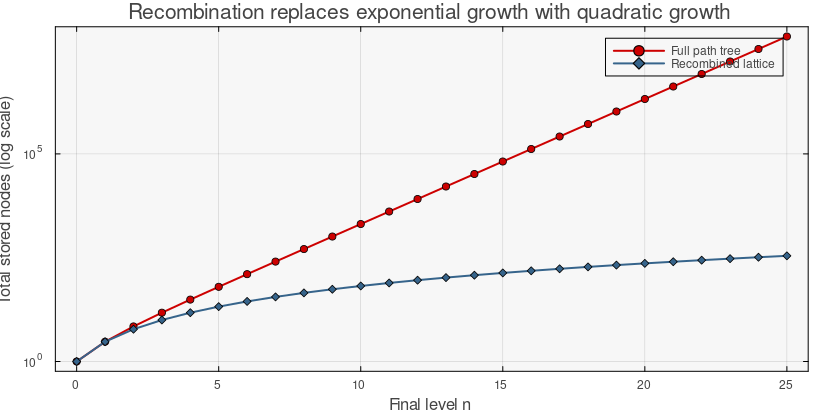

In [8]:
plot(
    node_counts.final_level, Float64.(node_counts.full_tree_nodes);
    yscale = :log10, marker = :circle, color = :red3, label = "Full path tree",
    xlabel = "Final level n", ylabel = "Total stored nodes (log scale)",
    title = "Recombination replaces exponential growth with quadratic growth",
    size = (820, 410),
)
plot!(node_counts.final_level, node_counts.recombined_total_nodes;
    marker = :diamond, color = :steelblue4, label = "Recombined lattice")

___

## 5. Time-dependent moves need not recombine

Suppose the factors depend on the step. After two steps, an up-then-down path has value $S_0u_1d_2$, while a down-then-up path has value $S_0d_1u_2$. These values merge only when

$$u_1d_2=d_1u_2\qquad\Longleftrightarrow\qquad \frac{u_1}{d_1}=\frac{u_2}{d_2}.$$

Constant factors satisfy this condition automatically. General time-dependent factors do not.

In [9]:
u_by_step = [1.10, 1.18]
d_by_step = [0.96, 0.91]

up_then_down = S₀ * u_by_step[1] * d_by_step[2]
down_then_up = S₀ * d_by_step[1] * u_by_step[2]

comparison = DataFrame(
    path = ["UD", "DU"],
    terminal_price = [up_then_down, down_then_up],
)
@assert !isapprox(up_then_down, down_then_up)
comparison

Row,path,terminal_price
,String,Float64
1,UD,100.1
2,DU,113.28


The move set can still be available with replacement even when the resulting structure does not recombine. Replacement describes what may be drawn next; recombination describes whether different histories arrive at the same state.

Once equivalent states are merged, the picture is a directed acyclic graph rather than a tree in the strict graph-theoretic sense. In finance, **binomial tree** remains common shorthand for either representation.

___

## Summary

This notebook separated three statements about a binomial price model: which moves are available at each step, when different move orders merge at the same price node, and what that merging saves in storage and computation.

> __Key Takeaways:__
>
> - **Asymmetry does not prevent recombination:** Constant positive move factors recombine because multiplication is commutative, so no reciprocal restriction between the up and down factors is required.
> - **Replacement and recombination are different statements:** Replacement keeps both moves available at every step, while recombination merges histories that reach the same state.
> - **Recombination saves computation only while the factors are constant:** The full path tree grows exponentially while the recombined lattice grows quadratically, and time-dependent move factors merge only under an additional ratio condition.

When a later lecture prices an asset on a lattice, check the constant-factor assumption first; it is what licenses the quadratic representation.

___

## Disclaimer and Risks

This notebook is for instruction only. A binomial lattice is a model whose conclusions depend on its move factors, probabilities, time step, and state assumptions. It is not investment or trading advice.

___